In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import sys
sys.path.append("..")
from src.load_data import load_data
data = load_data()
data.head()

,Unnamed: 0,title,location,price(L),rate_persqft,area_insqft,building_status
0,0,3 BHK Apartment,Nizampet,108.00,6000,1805,Under Construction
1,1,3 BHK Apartment,Bachupally,85.80,5500,1560,Under Construction
2,2,2 BHK Apartment,Dundigal,55.64,5200,1070,Under Construction
3,3,2 BHK Apartment,Pocharam,60.48,4999,1210,Under Construction
4,4,3 BHK Apartment,Kollur,113.00,5999,1900,Under Construction


1. The dataset is dominated by Residential Plots, 3 BHK Apartments, and 2 BHK Apartments, while villas, independent houses, and 5 BHK properties constitute only a small portion of the listings.<br></br>
2. The average property price increases with the number of BHKs, Villas and Independent Houses are generally more expensive than Apartments, with luxury properties (5+ BHK) commanding significantly higher prices.<br></br>

3. Mirkhanpet, Ameenpur, and Kondapur have the highest number of property listings in the dataset, indicating they are the most represented locations among the top 10 areas.<br></br>
4. Location has a significant impact on property prices, with premium areas such as Jubilee Hills, Kokapet, and Nanakramguda exhibiting substantially higher average property prices than locations such as Sadashivpet, Kolanupaka, and Narayan Kher.<br></br>

5. Property prices in the dataset range from approximately ₹1 Lakh to ₹36 Crores, indicating a wide variation in property values across different property types and locations.<br></br>

6. Most properties have a rate per square foot below ₹15,000, while a few premium properties with exceptionally high rates create a positively skewed distribution.<br></br>
7. Rate per square foot has a moderately strong positive correlation (0.63) with property price, indicating that properties with higher rates per square foot generally tend to have higher overall prices.<br></br>

8. Most properties have a area in sqaure feet below 10,000, while a few properties range upto 25000 area in sqft which create a positively skewed distribution.<br></br>
9. Area in square feet has a moderate positive correlation (0.51) with property price, indicating that properties with higher area per square foot generally tend to have higher overall prices.<br></br>

10. The dataset is primarily composed of New (1,378) and Under Construction (1,161) properties, while Resale properties (239) represent only a small portion of the listings.<br></br>
11. Property prices generally increase from New to Ready-to-Move properties, indicating that building status is an important factor influencing house prices.<br></br>

1) Distribution of Property type

In [4]:
data['title'].value_counts()

title
Residential Plot            1617
3 BHK Apartment              798
2 BHK Apartment              667
4 BHK Apartment              114
2 BHK Independent House      101
4 BHK Villa                   94
3 BHK Villa                   82
4 BHK Independent House       44
3 BHK Independent House       25
5 BHK Villa                   22
2 BHK Independent Floor       21
5 BHK Independent House       18
1 BHK Apartment               15
3 BHK Independent Floor        7
5 BHK Apartment                6
2 BHK Villa                    6
7 BHK Independent House        5
6 BHK Villa                    4
8 BHK Independent House        3
1 RK Studio Apartment          3
10 BHK Independent House       2
1 BHK Independent House        2
4 BHK Independent Floor        2
6 BHK Independent House        1
9 BHK Independent House        1
Name: count, dtype: int64

2) Does Property type affect Price ?

In [5]:
data.groupby('title')['price(L)'].mean().sort_values()

title
1 RK Studio Apartment         31.323333
1 BHK Apartment               35.328000
Residential Plot              42.393575
1 BHK Independent House       57.000000
2 BHK Independent Floor       66.619048
2 BHK Apartment               68.597091
2 BHK Villa                   85.333333
3 BHK Apartment              123.845251
2 BHK Independent House      139.707624
3 BHK Independent Floor      162.428571
3 BHK Independent House      184.562800
3 BHK Villa                  186.646951
5 BHK Independent House      221.388889
4 BHK Independent House      299.090909
9 BHK Independent House      300.000000
8 BHK Independent House      368.666667
4 BHK Apartment              431.977719
4 BHK Villa                  474.787234
6 BHK Independent House      480.000000
4 BHK Independent Floor      485.000000
10 BHK Independent House     590.000000
5 BHK Villa                  602.863636
7 BHK Independent House      890.000000
6 BHK Villa                 1042.500000
5 BHK Apartment             2222.8

3) Distribution of location

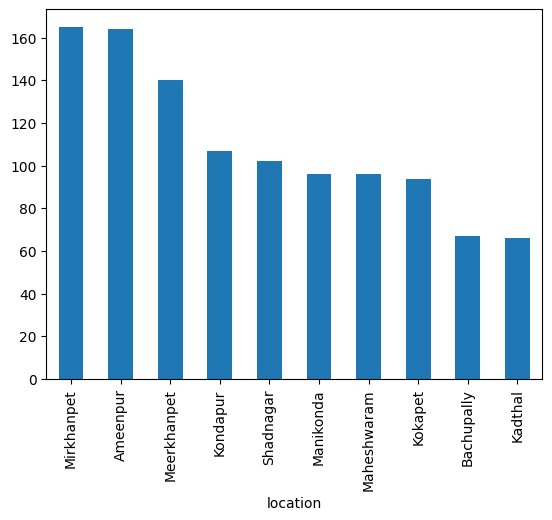

In [6]:
data['location'].value_counts().head(10).plot(kind='bar')
plt.show()

4) Does location affect the Price ?

In [7]:
data.groupby(['location','title'])['price(L)'].mean().sort_values(ascending=False)

location                title                  
Jubilee Hills           6 BHK Villa                3600.000000
Kokapet                 5 BHK Apartment            2454.333333
Nanakramguda            4 BHK Villa                2350.000000
Jubilee Hills           4 BHK Independent House    2000.000000
Khajiguda               5 BHK Apartment            1991.333333
                                                      ...     
Hyderabad Warangal Hwy  Residential Plot              7.000000
Batasingaram            Residential Plot              6.410000
Kolanupaka              Residential Plot              6.075000
Sadasivpet              Residential Plot              5.486667
Narayan Kher            Residential Plot              4.000000
Name: price(L), Length: 712, dtype: float64

5) Distribution of property price

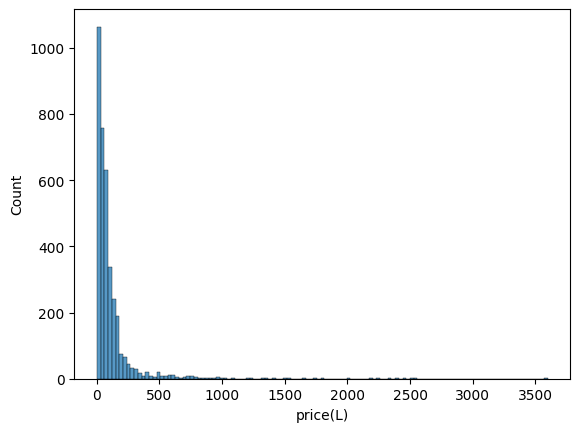

In [8]:
sns.histplot(data=data,x='price(L)')
plt.show()

6) Distribution of rate per square feet

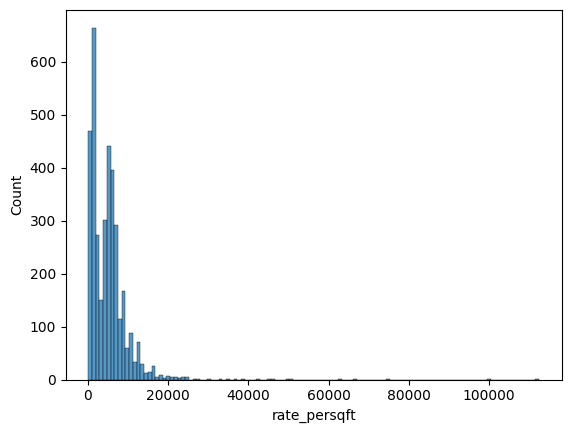

In [9]:
sns.histplot(data=data,x='rate_persqft')
plt.show()

7) Does rate per sqft affect price of the property ?

In [10]:
data[['rate_persqft','price(L)']].corr()

,rate_persqft,price(L)
rate_persqft,1.000000,0.628859
price(L),0.628859,1.000000


8) Distribution of area in square feet

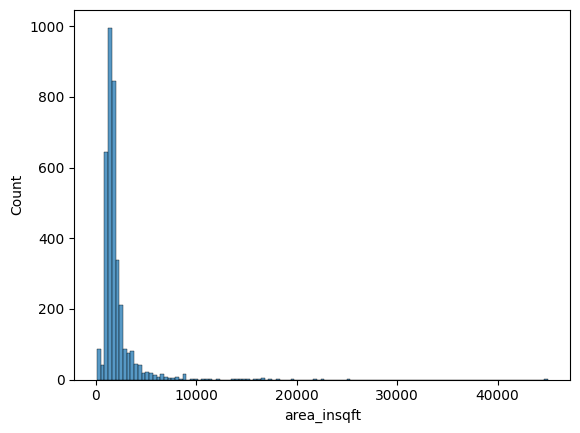

In [11]:
sns.histplot(data=data,x='area_insqft')
plt.show()

9) Does area in sqft affect price of the property?

In [12]:
data[['area_insqft','price(L)']].corr()

,area_insqft,price(L)
area_insqft,1.000000,0.516428
price(L),0.516428,1.000000


10) Distribution of building status ?

In [13]:
data['building_status'].value_counts()

building_status
New                   1378
Under Construction    1161
Ready to move          882
Resale                 239
Name: count, dtype: int64

11) How building status related to price ?

In [14]:
data.groupby('building_status')['price(L)'].mean().sort_values()

building_status
New                    36.067743
Resale                 78.866360
Under Construction    158.252506
Ready to move         168.870238
Name: price(L), dtype: float64

12) Heatmap of all numeric columns in dataset

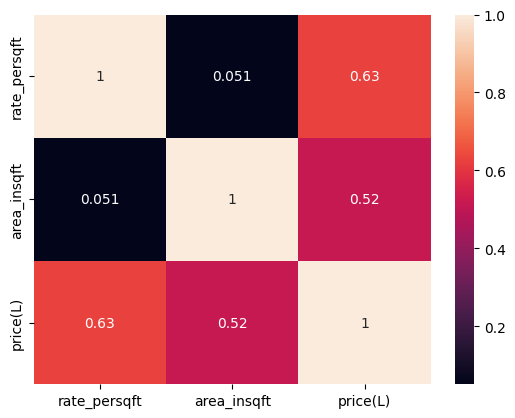

In [15]:
corr = data[['rate_persqft','area_insqft','price(L)']].corr()
sns.heatmap(corr,annot=True)
plt.show()